### CONFIGURAÇÃO E FUNÇÕES

In [1]:
import os
import torchio as tio

# pra usar cpu, descomentar linha abaixo
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import math
import nibabel as nib

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, CSVLogger, EarlyStopping
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras import layers, models, Input, Model

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np
import gc
import seaborn as sns

from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from PIL import Image
import tempfile
from math import ceil
import random
from tensorflow.keras import backend as K
import sys

#import wandb

2026-02-09 15:00:19.972221: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-09 15:00:20.956041: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-09 15:00:21.203551: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-09 15:00:23.152974: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
%load_ext autoreload
%autoreload 2

# Pega o diretório atual e sobe um nível ('..')
project_root = os.path.abspath('..')

# Adiciona este diretório ao sys.path se ele ainda não estiver lá
if project_root not in sys.path:
    sys.path.append(project_root)

# --- Seus imports originais ---
import utils.processamento_dados as proc_dados
import utils.metricas_e_visualizacao as met_vil

In [3]:
from tensorflow.keras import mixed_precision

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # Evita uso excessivo de memória
        print("GPU habilitada com sucesso!")
        print("Memory Growth habilitado para a GPU")
    except RuntimeError as e:
        print(e)

mixed_precision.set_global_policy("mixed_float16")

tf.get_logger().setLevel('ERROR')

GPU habilitada com sucesso!
Memory Growth habilitado para a GPU


I0000 00:00:1770660077.154722 3179980 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1770660077.160107 3179980 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1770660077.160153 3179980 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.


In [4]:
# FUNÇÕES
def create_model_3d(input_shape, n_classes):
    inputs = Input(shape=input_shape)  # (D, H, W, C)

    # Camada 1
    x = layers.Conv3D(4, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Camada 2
    x = layers.Conv3D(8, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Camada 3
    x = layers.Conv3D(16, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Flatten e densas
    x = layers.Flatten()(x)

    x = layers.Dense(16, kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)

    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    return model

In [5]:
dir_base = "/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn"

# Nome das classes
# adni_class_names = ['cn', 'mci', 'ad']
adni_class_names = ['cn', 'ad']
# oasis_class_names = ['0.0', '0.5', '1.0']
oasis_class_names = ['0.0', '1.0']

n_adni_classes = len(adni_class_names)
n_oasis_classes = len(oasis_class_names)

fine_tunning_labels = adni_class_names

In [ ]:
# Definindo caminhos
train_dir = f'{dir_base}/ADNI/ADNI_NORMALIZED/train'
val_dir = f'{dir_base}/ADNI/ADNI_NORMALIZED/validation'
test_dir = f'{dir_base}/ADNI/ADNI_NORMALIZED/test'

results_dir_base = f'{dir_base}/ADNI/ADNI_NORMALIZED/results/experimentos_oasis_augment'
os.makedirs(results_dir_base, exist_ok=True)

transformations = ['noise']

In [ ]:
n = len(os.listdir(results_dir_base))

if (n > 0):
    if (len(os.listdir(os.path.join(results_dir_base, f'test_experimentos_{n}'))) < 2): 
        n -= 1

folder_name = f"test_experimentos_{str(n+1)}"
results_dir = os.path.join(results_dir_base, folder_name)
os.makedirs(results_dir, exist_ok=True)
print(f"pasta {folder_name} criada")

# Pré-treino

In [ ]:
# # Experimento 2
# train_images, train_labels, train_paths, class_labels = proc_dados.load_nifti_data_balanced_preallocated(
#     train_dir, 
#     adni_class_names, 
#     augment=True, 
#     augmentation_factor=3,      # Cria 3 imagens para cada 1 original
#     include_intensity=False,    # Só Geometria
#     transform_probability=1.0   # 100% de chance de transformar (nenhuma original sobra)
# )

# Experimento 4
# train_images, train_labels, train_paths, class_labels = proc_dados.load_nifti_data_balanced_preallocated(
#     train_dir, 
#     adni_class_names, 
#     augment=True, 
#     augmentation_factor=3,      # Cria 3 imagens para cada 1 original
#     include_intensity=False,    # Só Geometria
#     transform_probability=0.3   # 30% chance de transformar, 70% de manter original
# )

# # Experimento 6
# train_images, train_labels, train_paths, class_labels = proc_dados.load_nifti_data_balanced_preallocated(
#     train_dir, 
#     adni_class_names, 
#     augment=True, 
#     augmentation_factor=3,      # Cria 3 imagens para cada 1 original
#     include_intensity=True,     # Geometria + Intensidade
#     transform_probability=1.0   # 100% de chance de transformar (nenhuma original sobra)
# )

# # Experimento 8
# train_images, train_labels, train_paths, class_labels = proc_dados.load_nifti_data_balanced_preallocated(
#     train_dir, 
#     adni_class_names, 
#     augment=True, 
#     augmentation_factor=3,      # Cria 3 imagens para cada 1 original
#     include_intensity=True,    # Geometria + Intensidade
#     transform_probability=0.3   # 30% chance de transformar, 70% de manter original
# )

# -----------------------------------------------------------------------------------------------------------------------
# novos experimentos

# Experimento 1
# train_images, train_labels, train_paths, class_labels = proc_dados.load_nifti_data_balanced_preallocated(
#     train_dir, 
#     adni_class_names, 
#     augment=True, 
#     augmentation_factor=1,      # Só as originais
#     include_intensity=False,     # Intensidade e geometria
#     transform_probability=1     # Cria novas transformações sempre
# )

# Experimento 2
train_images, train_labels, train_paths, class_labels = proc_dados.load_nifti_data_balanced_preallocated(
    train_dir, 
    adni_class_names, 
    augment=False, 
    augmentation_factor=4,      # Cria 3 imagens + 1 original
    include_intensity=False,     # Intensidade e geometria
    transform_probability=1     # Cria novas transformações sempre
)

# Experimento 3
# train_images, train_labels, train_paths, class_labels = proc_dados.load_nifti_data_balanced_preallocated(
#     train_dir, 
#     adni_class_names, 
#     augment=True, 
#     augmentation_factor=8,      # Cria 7 imagens para cada 1 original
#     include_intensity=True,     # Intensidade e geometria
#     transform_probability=1     # Cria novas transformações sempre
# )

print(f"N treino: {len(train_paths)}")

val_images, val_labels, val_paths, _ = proc_dados.load_nifti_data_balanced_preallocated(
    val_dir, 
    adni_class_names, 
    augment=False
)

print(f"N validation: {len(val_paths)}")

In [ ]:
# ==============================================================================
# CONFIGURAÇÃO DA FASE DE TREINAMENTO
# ==============================================================================
# 1 = Pré-treinamento
# 2 = Fine-tuning
fase_atual = 1

# Defina os caminhos base para salvar/carregar
PATH_PRETREINADO = os.path.join(results_dir, "modelo_pretrained.keras")
PATH_FINETUNED = os.path.join(results_dir, "modelo_final.keras")

In [ ]:
print("--- INICIANDO FASE 1: PRÉ-TREINAMENTO ---")

# Cria modelo do zero
model = create_model_3d(train_images[0].shape, 2)

# Compilação padrão
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
                loss='binary_crossentropy', 
                metrics=['binary_accuracy'])

model.summary()

In [ ]:
batch_size = 8

steps_per_epoch = math.ceil(len(train_images) / batch_size)
validation_steps = math.ceil(len(val_images) / batch_size)

train_generator = proc_dados.nifti_data_generator_3d(train_images, train_labels, batch_size)
val_generator = proc_dados.nifti_data_generator_3d(val_images, val_labels, batch_size)

# Callbacks
csv_filename = 'log_treino_fase1.csv'
checkpoint_path = PATH_PRETREINADO
backup_path = os.path.join(results_dir, "last_model.keras")

callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=20, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1),
    CSVLogger(os.path.join(results_dir, csv_filename)),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_binary_accuracy', save_best_only=True, mode='max'),
    ModelCheckpoint(filepath=backup_path, save_best_only=False)
]

In [ ]:
epochs = 200

print(f"Iniciando treinamento FASE {fase_atual} por {epochs} épocas...")

history_pretrained = model.fit(
    train_generator,
    epochs=epochs,
    verbose=1,
    validation_data=val_generator,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks_list
)

In [ ]:
# Plotando o histórico de treinamento após o treinamento
os.makedirs(f"{results_dir}/pretrained", exist_ok=True)
met_vil.plot_training_history(history_pretrained, f"{results_dir}/pretrained", 'pre_training_adni_training_history.png')

### PREDIÇÃO VALIDAÇÃO PRE TREINO

In [ ]:
# Realizar predições para dados do conjunto validação
val_pred_labels, val_true_labels, val_pred = met_vil.get_predictions(val_images, val_labels, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(val_true_labels, val_pred_labels, f"{results_dir}/pretrained", 'validation_adni_pre_train')

# Obter matriz de confusão
met_vil.plot_confusion_matrix(val_true_labels, val_pred_labels, f"{results_dir}/pretrained", 'validation_adni_pre_train', ["cn", "ad"])

# Criar pdf com predições
val_pdf_path = os.path.join(f"{results_dir}/pretrained", "validation_adni_predictions_pre_train.pdf")
met_vil.create_pdf(val_paths, val_images, val_true_labels, val_pred_labels, val_pred, val_pdf_path, ["cn", "ad"])

### PREDIÇÃO TESTE PRE TREINO

In [ ]:
test_images, test_labels, test_paths, _ = proc_dados.load_nifti_data_balanced_preallocated(test_dir, adni_class_names)

# Realizar predições para dados do conjunto validação
test_pred_labels, test_true_labels, test_pred = met_vil.get_predictions(test_images, test_labels, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(test_true_labels, test_pred_labels, f"{results_dir}/pretrained", 'test_adni_pre_train')

# Obter matriz de confusão
met_vil.plot_confusion_matrix(test_true_labels, test_pred_labels, f"{results_dir}/pretrained", 'test_adni_pre_train', ["cn", "ad"])

# Criar pdf com predições
test_pdf_path = os.path.join(f"{results_dir}/pretrained", "test_adni_predictions_pre_train.pdf")
met_vil.create_pdf(test_paths, test_images, test_true_labels, test_pred_labels, test_pred, test_pdf_path, ["cn", "ad"])

# Transfer learning

In [ ]:
# Limpeza de memoria pre treino
print("Limpando memoria do pre treino...")
del train_images, train_labels, val_images, val_labels, model
gc.collect()
K.clear_session()

In [13]:
# fine_tunning_train_dir = f'{dir_base}/OASIS/OASIS_1_FSL_NORMALIZED/train'
fine_tunning_train_dir = f'{dir_base}/ADNI/ADNI_3_4_NORMALIZED/train'
# model_path = PATH_PRETREINADO
results_dir = "/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/experimentos_oasis_augment/test_experimentos_8"
os.makedirs(results_dir, exist_ok=True)
model_path = os.path.join("/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/experimentos_oasis_augment/test_experimentos_5", "modelo_pretrained.keras")

--- CONFIGURAÇÃO EXPERIMENTO (BALANCED CV) ---
Fator de Aumento Alvo: 3x (sobre a classe majoritária)
Incluir Intensidade: False
Probabilidade Transform: 1
----------------------------------------------
Carregando dados ORIGINAIS (Raw) para memória...
Passo 1: Analisando diretórios...
   > Classe 'cn': 300 originais.
   > Classe 'ad': 128 originais.
   > Alvo final: ~300 por classe.
   > 'cn': 1 original + 0 possíveis aumentos por imagem.
   > 'ad': 1 original + 0 possíveis aumentos por imagem.
Passo 2: Alocando para 428 imagens...
Progresso: 400/428
Concluído.
Total de dados carregados: 428

INICIANDO FOLD 1/5
   > Pesos Originais (Balanced): [0.7125     1.67647059]
   > Pesos FINAIS (Suavizados): {0: 0.7892877931139648, 1: 1.2107122068860352}
Epoch 1/100


/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 38 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - auc: 0.6732 - binary_accuracy: 0.6373 - loss: 0.8046

240/240 ━━━━━━━━━━━━━━━━━━━━ 174s 688ms/step - auc: 0.7338 - binary_accuracy: 0.6750 - loss: 0.7491 - val_auc: 0.9167 - val_binary_accuracy: 0.8140 - val_loss: 0.5144 - learning_rate: 5.0000e-04
Epoch 2/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - auc: 0.7966 - binary_accuracy: 0.7389 - loss: 0.6686

240/240 ━━━━━━━━━━━━━━━━━━━━ 150s 629ms/step - auc: 0.7954 - binary_accuracy: 0.7281 - loss: 0.6704 - val_auc: 0.9229 - val_binary_accuracy: 0.8372 - val_loss: 0.4846 - learning_rate: 5.0000e-04
Epoch 3/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 677ms/step - auc: 0.8177 - binary_accuracy: 0.7395 - loss: 0.6382

...

240/240 ━━━━━━━━━━━━━━━━━━━━ 167s 699ms/step - auc: 0.9293 - binary_accuracy: 0.8562 - loss: 0.3952 - val_auc: 0.9409 - val_binary_accuracy: 0.8721 - val_loss: 0.3824 - learning_rate: 3.1250e-05
Epoch 42/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 718ms/step - auc: 0.9280 - binary_accuracy: 0.8360 - loss: 0.3965

240/240 ━━━━━━━━━━━━━━━━━━━━ 173s 722ms/step - auc: 0.9335 - binary_accuracy: 0.8443 - loss: 0.3852 - val_auc: 0.9383 - val_binary_accuracy: 0.8721 - val_loss: 0.3905 - learning_rate: 3.1250e-05
Epoch 43/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - auc: 0.9274 - binary_accuracy: 0.8528 - loss: 0.3969

240/240 ━━━━━━━━━━━━━━━━━━━━ 166s 693ms/step - auc: 0.9250 - binary_accuracy: 0.8469 - loss: 0.4045 - val_auc: 0.9409 - val_binary_accuracy: 0.8721 - val_loss: 0.3823 - learning_rate: 3.1250e-05
Epoch 44/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 686ms/step - auc: 0.9124 - binary_accuracy: 0.8302 - loss: 0.4343

240/240 ━━━━━━━━━━━━━━━━━━━━ 165s 690ms/step - auc: 0.9279 - binary_accuracy: 0.8552 - loss: 0.3981 - val_auc: 0.9404 - val_binary_accuracy: 0.8721 - val_loss: 0.3811 - learning_rate: 3.1250e-05
Epoch 45/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 708ms/step - auc: 0.9280 - binary_accuracy: 0.8556 - loss: 0.4011
Epoch 45: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.


240/240 ━━━━━━━━━━━━━━━━━━━━ 170s 713ms/step - auc: 0.9209 - binary_accuracy: 0.8490 - loss: 0.4127 - val_auc: 0.9391 - val_binary_accuracy: 0.8721 - val_loss: 0.3830 - learning_rate: 3.1250e-05
Epoch 45: early stopping
Restoring model weights from the end of the best epoch: 30.


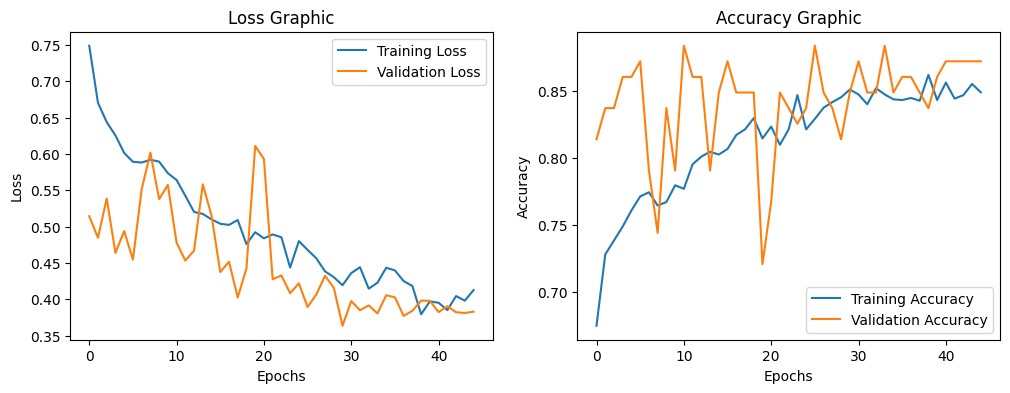

11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 331ms/step
              precision    recall  f1-score   support

           0       0.87      0.92      0.89        60
           1       0.78      0.69      0.73        26

    accuracy                           0.85        86
   macro avg       0.83      0.80      0.81        86
weighted avg       0.85      0.85      0.85        86



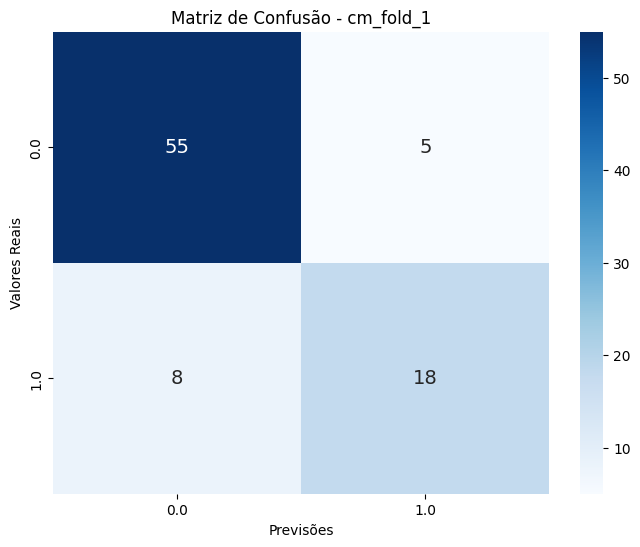


INICIANDO FOLD 2/5
   > Pesos Originais (Balanced): [0.7125     1.67647059]
   > Pesos FINAIS (Suavizados): {0: 0.7892877931139648, 1: 1.2107122068860352}
Epoch 1/100


/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 38 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 681ms/step - auc: 0.7775 - binary_accuracy: 0.7054 - loss: 0.7203

240/240 ━━━━━━━━━━━━━━━━━━━━ 183s 728ms/step - auc: 0.8168 - binary_accuracy: 0.7391 - loss: 0.6692 - val_auc: 0.4232 - val_binary_accuracy: 0.3605 - val_loss: 1.1648 - learning_rate: 5.0000e-04
Epoch 2/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 673ms/step - auc: 0.8254 - binary_accuracy: 0.7519 - loss: 0.6371

240/240 ━━━━━━━━━━━━━━━━━━━━ 162s 678ms/step - auc: 0.8399 - binary_accuracy: 0.7651 - loss: 0.6214 - val_auc: 0.8363 - val_binary_accuracy: 0.8023 - val_loss: 0.6315 - learning_rate: 5.0000e-04
Epoch 3/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - auc: 0.8405 - binary_accuracy: 0.7583 - loss: 0.6140

...

240/240 ━━━━━━━━━━━━━━━━━━━━ 168s 701ms/step - auc: 0.9390 - binary_accuracy: 0.8755 - loss: 0.3726 - val_auc: 0.8632 - val_binary_accuracy: 0.8372 - val_loss: 0.6172 - learning_rate: 3.1250e-05
Epoch 43/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 671ms/step - auc: 0.9331 - binary_accuracy: 0.8714 - loss: 0.3863

240/240 ━━━━━━━━━━━━━━━━━━━━ 161s 675ms/step - auc: 0.9420 - binary_accuracy: 0.8854 - loss: 0.3662 - val_auc: 0.8620 - val_binary_accuracy: 0.8372 - val_loss: 0.5975 - learning_rate: 3.1250e-05
Epoch 44/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - auc: 0.9556 - binary_accuracy: 0.8933 - loss: 0.3285

240/240 ━━━━━━━━━━━━━━━━━━━━ 165s 692ms/step - auc: 0.9507 - binary_accuracy: 0.8870 - loss: 0.3424 - val_auc: 0.8611 - val_binary_accuracy: 0.8372 - val_loss: 0.6169 - learning_rate: 3.1250e-05
Epoch 45/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 662ms/step - auc: 0.9501 - binary_accuracy: 0.8844 - loss: 0.3526

240/240 ━━━━━━━━━━━━━━━━━━━━ 159s 667ms/step - auc: 0.9517 - binary_accuracy: 0.8818 - loss: 0.3451 - val_auc: 0.8643 - val_binary_accuracy: 0.8372 - val_loss: 0.5880 - learning_rate: 3.1250e-05
Epoch 46/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - auc: 0.9495 - binary_accuracy: 0.8921 - loss: 0.3458
Epoch 46: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.


240/240 ━━━━━━━━━━━━━━━━━━━━ 156s 652ms/step - auc: 0.9487 - binary_accuracy: 0.8911 - loss: 0.3472 - val_auc: 0.8607 - val_binary_accuracy: 0.8372 - val_loss: 0.6062 - learning_rate: 3.1250e-05
Epoch 46: early stopping
Restoring model weights from the end of the best epoch: 31.


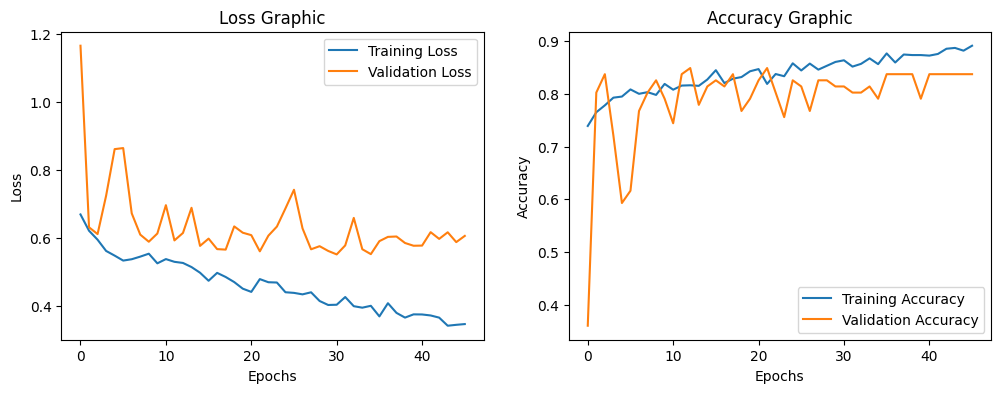

11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 199ms/step
              precision    recall  f1-score   support

           0       0.83      0.92      0.87        60
           1       0.75      0.58      0.65        26

    accuracy                           0.81        86
   macro avg       0.79      0.75      0.76        86
weighted avg       0.81      0.81      0.81        86



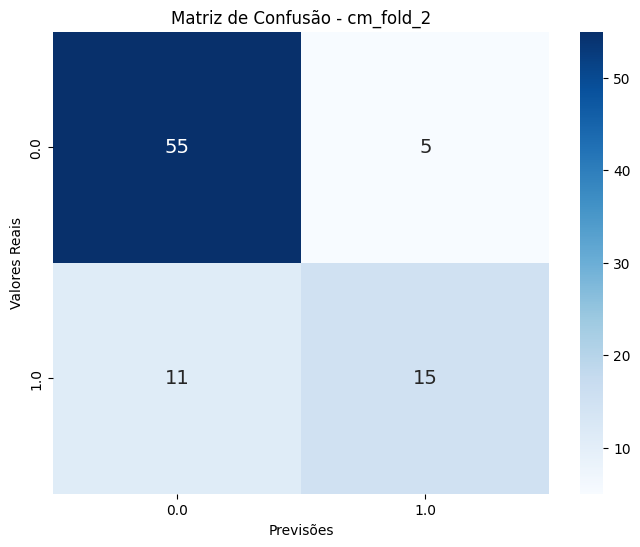


INICIANDO FOLD 3/5
   > Pesos Originais (Balanced): [0.7125     1.67647059]
   > Pesos FINAIS (Suavizados): {0: 0.7892877931139648, 1: 1.2107122068860352}
Epoch 1/100


/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 38 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 673ms/step - auc: 0.7052 - binary_accuracy: 0.6481 - loss: 0.8401

240/240 ━━━━━━━━━━━━━━━━━━━━ 180s 717ms/step - auc: 0.7480 - binary_accuracy: 0.6844 - loss: 0.7847 - val_auc: 0.9402 - val_binary_accuracy: 0.8837 - val_loss: 0.4920 - learning_rate: 5.0000e-04
Epoch 2/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 673ms/step - auc: 0.7973 - binary_accuracy: 0.7231 - loss: 0.7056

240/240 ━━━━━━━━━━━━━━━━━━━━ 162s 678ms/step - auc: 0.8072 - binary_accuracy: 0.7344 - loss: 0.6831 - val_auc: 0.9112 - val_binary_accuracy: 0.8372 - val_loss: 0.5160 - learning_rate: 5.0000e-04
Epoch 3/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 719ms/step - auc: 0.8191 - binary_accuracy: 0.7457 - loss: 0.6501

...

240/240 ━━━━━━━━━━━━━━━━━━━━ 165s 689ms/step - auc: 0.9144 - binary_accuracy: 0.8385 - loss: 0.4203 - val_auc: 0.9093 - val_binary_accuracy: 0.8605 - val_loss: 0.4462 - learning_rate: 1.5625e-05
Epoch 41/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 702ms/step - auc: 0.9395 - binary_accuracy: 0.8629 - loss: 0.3720

240/240 ━━━━━━━━━━━━━━━━━━━━ 169s 707ms/step - auc: 0.9259 - binary_accuracy: 0.8469 - loss: 0.3960 - val_auc: 0.9101 - val_binary_accuracy: 0.8721 - val_loss: 0.4350 - learning_rate: 1.5625e-05
Epoch 42/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 667ms/step - auc: 0.9190 - binary_accuracy: 0.8442 - loss: 0.4077

240/240 ━━━━━━━━━━━━━━━━━━━━ 160s 671ms/step - auc: 0.9209 - binary_accuracy: 0.8464 - loss: 0.4086 - val_auc: 0.9067 - val_binary_accuracy: 0.8721 - val_loss: 0.4500 - learning_rate: 1.5625e-05
Epoch 43/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 696ms/step - auc: 0.9190 - binary_accuracy: 0.8357 - loss: 0.4104

240/240 ━━━━━━━━━━━━━━━━━━━━ 168s 701ms/step - auc: 0.9205 - binary_accuracy: 0.8365 - loss: 0.4077 - val_auc: 0.9152 - val_binary_accuracy: 0.8721 - val_loss: 0.4344 - learning_rate: 1.5625e-05
Epoch 44/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 723ms/step - auc: 0.9064 - binary_accuracy: 0.8276 - loss: 0.4296
Epoch 44: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.


240/240 ━━━━━━━━━━━━━━━━━━━━ 174s 728ms/step - auc: 0.9158 - binary_accuracy: 0.8313 - loss: 0.4167 - val_auc: 0.9085 - val_binary_accuracy: 0.8721 - val_loss: 0.4458 - learning_rate: 1.5625e-05
Epoch 44: early stopping
Restoring model weights from the end of the best epoch: 29.


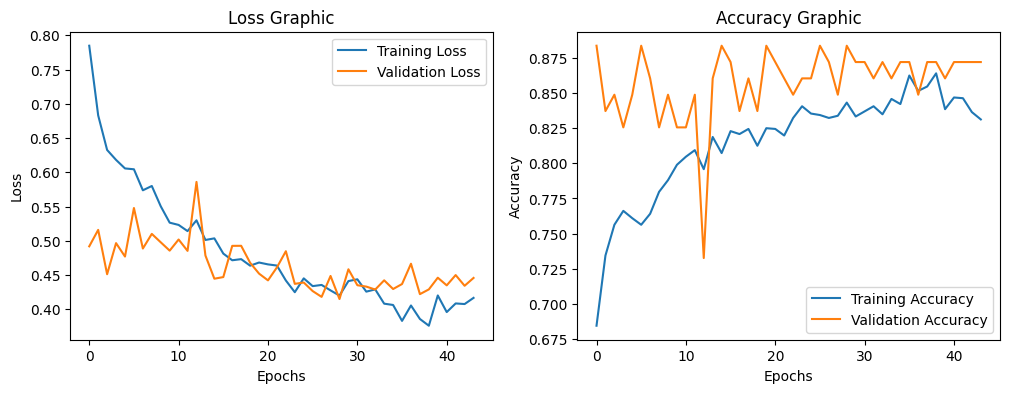

11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 225ms/step
              precision    recall  f1-score   support

           0       0.89      0.95      0.92        60
           1       0.86      0.73      0.79        26

    accuracy                           0.88        86
   macro avg       0.88      0.84      0.86        86
weighted avg       0.88      0.88      0.88        86



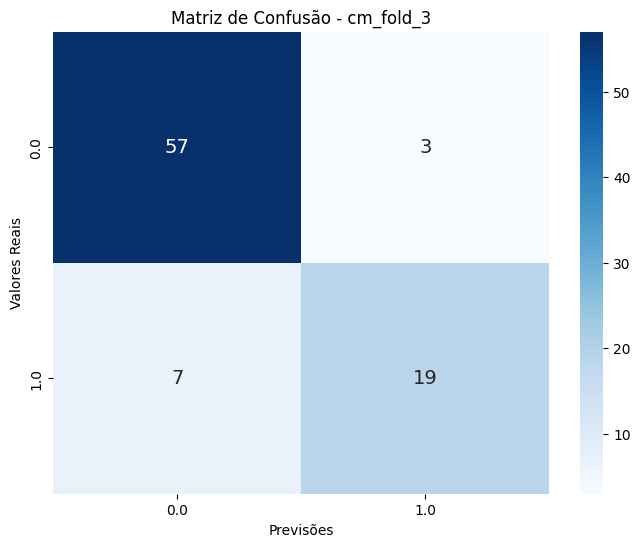


INICIANDO FOLD 4/5
   > Pesos Originais (Balanced): [0.71458333 1.66504854]
   > Pesos FINAIS (Suavizados): {0: 0.7916197380477135, 1: 1.2083802619522865}
Epoch 1/100


/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 38 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 671ms/step - auc: 0.7171 - binary_accuracy: 0.6553 - loss: 0.8130

240/240 ━━━━━━━━━━━━━━━━━━━━ 182s 720ms/step - auc: 0.7737 - binary_accuracy: 0.6964 - loss: 0.7486 - val_auc: 0.4498 - val_binary_accuracy: 0.3412 - val_loss: 1.1243 - learning_rate: 5.0000e-04
Epoch 2/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - auc: 0.7999 - binary_accuracy: 0.7260 - loss: 0.6762

240/240 ━━━━━━━━━━━━━━━━━━━━ 160s 671ms/step - auc: 0.8213 - binary_accuracy: 0.7422 - loss: 0.6520 - val_auc: 0.8591 - val_binary_accuracy: 0.8353 - val_loss: 0.5934 - learning_rate: 5.0000e-04
Epoch 3/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 739ms/step - auc: 0.8261 - binary_accuracy: 0.7475 - loss: 0.6324

...

240/240 ━━━━━━━━━━━━━━━━━━━━ 175s 734ms/step - auc: 0.9390 - binary_accuracy: 0.8760 - loss: 0.3728 - val_auc: 0.9037 - val_binary_accuracy: 0.8824 - val_loss: 0.4981 - learning_rate: 7.8125e-06
Epoch 53/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 718ms/step - auc: 0.9441 - binary_accuracy: 0.8751 - loss: 0.3679

240/240 ━━━━━━━━━━━━━━━━━━━━ 173s 723ms/step - auc: 0.9409 - binary_accuracy: 0.8703 - loss: 0.3713 - val_auc: 0.9044 - val_binary_accuracy: 0.8824 - val_loss: 0.4985 - learning_rate: 7.8125e-06
Epoch 54/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 684ms/step - auc: 0.9484 - binary_accuracy: 0.8876 - loss: 0.3519

240/240 ━━━━━━━━━━━━━━━━━━━━ 165s 689ms/step - auc: 0.9415 - binary_accuracy: 0.8755 - loss: 0.3658 - val_auc: 0.9034 - val_binary_accuracy: 0.8824 - val_loss: 0.4962 - learning_rate: 7.8125e-06
Epoch 55/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 699ms/step - auc: 0.9260 - binary_accuracy: 0.8565 - loss: 0.4042

240/240 ━━━━━━━━━━━━━━━━━━━━ 168s 704ms/step - auc: 0.9331 - binary_accuracy: 0.8630 - loss: 0.3876 - val_auc: 0.9046 - val_binary_accuracy: 0.8824 - val_loss: 0.4973 - learning_rate: 7.8125e-06
Epoch 56/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 704ms/step - auc: 0.9359 - binary_accuracy: 0.8668 - loss: 0.3769
Epoch 56: ReduceLROnPlateau reducing learning rate to 3.906250185536919e-06.


240/240 ━━━━━━━━━━━━━━━━━━━━ 169s 709ms/step - auc: 0.9396 - binary_accuracy: 0.8682 - loss: 0.3676 - val_auc: 0.9037 - val_binary_accuracy: 0.8824 - val_loss: 0.4989 - learning_rate: 7.8125e-06
Epoch 56: early stopping
Restoring model weights from the end of the best epoch: 41.


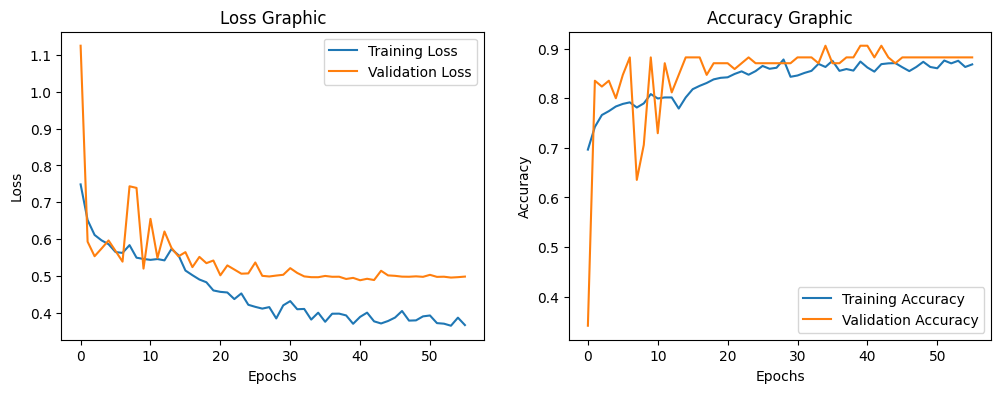

11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 276ms/step
              precision    recall  f1-score   support

           0       0.91      0.97      0.94        60
           1       0.90      0.76      0.83        25

    accuracy                           0.91        85
   macro avg       0.91      0.86      0.88        85
weighted avg       0.91      0.91      0.90        85



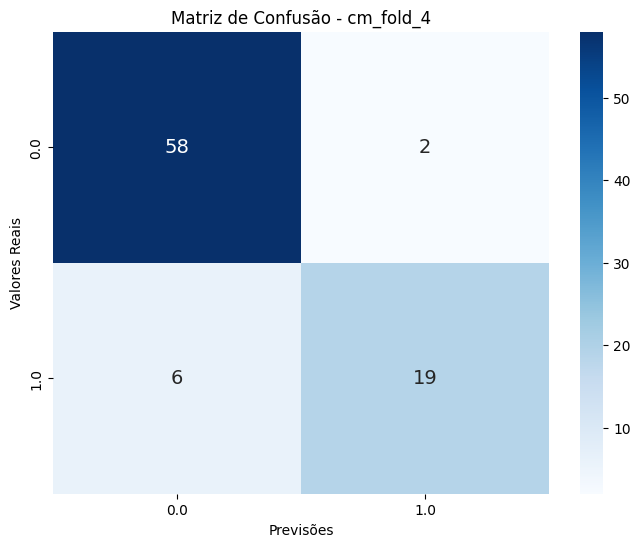


INICIANDO FOLD 5/5
   > Pesos Originais (Balanced): [0.71458333 1.66504854]
   > Pesos FINAIS (Suavizados): {0: 0.7916197380477135, 1: 1.2083802619522865}
Epoch 1/100


/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 38 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - auc: 0.6555 - binary_accuracy: 0.6132 - loss: 0.8697

240/240 ━━━━━━━━━━━━━━━━━━━━ 183s 728ms/step - auc: 0.7421 - binary_accuracy: 0.6818 - loss: 0.7954 - val_auc: 0.8515 - val_binary_accuracy: 0.7412 - val_loss: 0.6107 - learning_rate: 5.0000e-04
Epoch 2/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 700ms/step - auc: 0.8214 - binary_accuracy: 0.7437 - loss: 0.6751

240/240 ━━━━━━━━━━━━━━━━━━━━ 169s 705ms/step - auc: 0.8218 - binary_accuracy: 0.7453 - loss: 0.6642 - val_auc: 0.8700 - val_binary_accuracy: 0.7765 - val_loss: 0.5812 - learning_rate: 5.0000e-04
Epoch 3/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 717ms/step - auc: 0.8273 - binary_accuracy: 0.7646 - loss: 0.6554

...

240/240 ━━━━━━━━━━━━━━━━━━━━ 169s 708ms/step - auc: 0.9349 - binary_accuracy: 0.8672 - loss: 0.3867 - val_auc: 0.8627 - val_binary_accuracy: 0.7765 - val_loss: 0.5601 - learning_rate: 3.1250e-05
Epoch 37/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - auc: 0.9342 - binary_accuracy: 0.8648 - loss: 0.3803

240/240 ━━━━━━━━━━━━━━━━━━━━ 166s 693ms/step - auc: 0.9296 - binary_accuracy: 0.8604 - loss: 0.3937 - val_auc: 0.8306 - val_binary_accuracy: 0.7294 - val_loss: 0.5984 - learning_rate: 3.1250e-05
Epoch 38/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 711ms/step - auc: 0.9211 - binary_accuracy: 0.8546 - loss: 0.4018

240/240 ━━━━━━━━━━━━━━━━━━━━ 171s 715ms/step - auc: 0.9335 - binary_accuracy: 0.8589 - loss: 0.3874 - val_auc: 0.8583 - val_binary_accuracy: 0.7882 - val_loss: 0.5658 - learning_rate: 3.1250e-05
Epoch 39/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 718ms/step - auc: 0.9246 - binary_accuracy: 0.8529 - loss: 0.4083

240/240 ━━━━━━━━━━━━━━━━━━━━ 173s 723ms/step - auc: 0.9307 - binary_accuracy: 0.8557 - loss: 0.3927 - val_auc: 0.8580 - val_binary_accuracy: 0.7765 - val_loss: 0.5524 - learning_rate: 3.1250e-05
Epoch 40/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - auc: 0.9436 - binary_accuracy: 0.8745 - loss: 0.3652
Epoch 40: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.


240/240 ━━━━━━━━━━━━━━━━━━━━ 165s 692ms/step - auc: 0.9380 - binary_accuracy: 0.8630 - loss: 0.3765 - val_auc: 0.8464 - val_binary_accuracy: 0.7294 - val_loss: 0.5695 - learning_rate: 3.1250e-05
Epoch 40: early stopping
Restoring model weights from the end of the best epoch: 25.


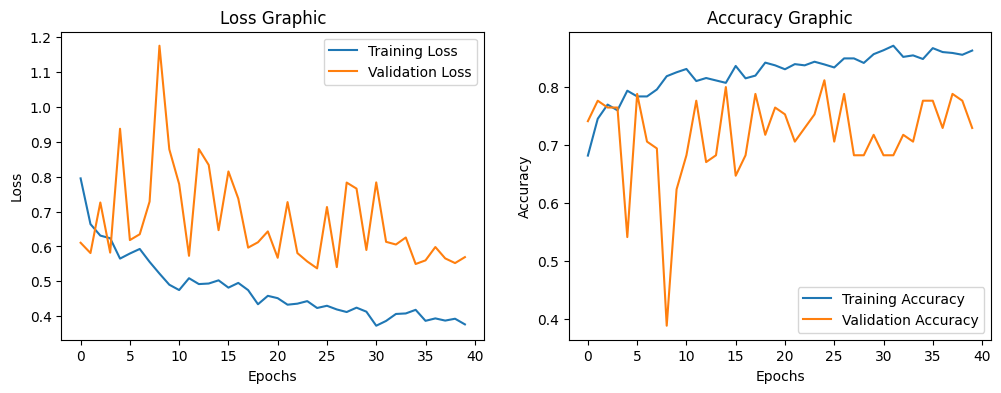

11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 202ms/step
              precision    recall  f1-score   support

           0       0.83      0.92      0.87        60
           1       0.74      0.56      0.64        25

    accuracy                           0.81        85
   macro avg       0.79      0.74      0.75        85
weighted avg       0.80      0.81      0.80        85



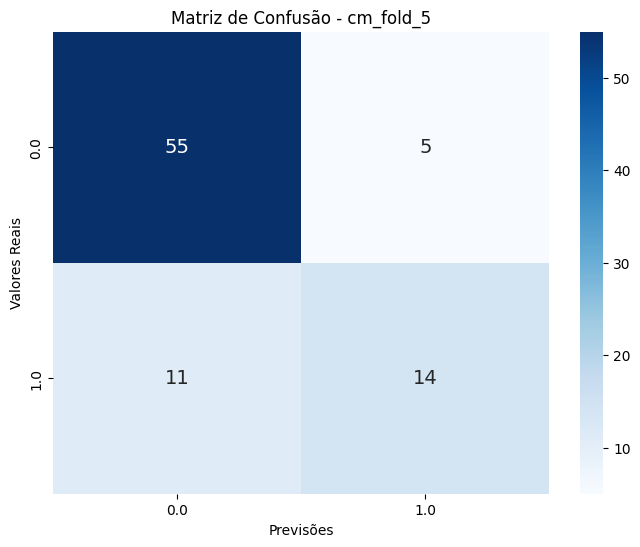

In [14]:
# ==============================================================================
# 1. CONFIGURAÇÃO DOS EXPERIMENTOS
# ==============================================================================
# Experimento 2
# EXP_AUGMENTATION_FACTOR = 3
# EXP_INCLUDE_INTENSITY = False    
# EXP_TRANSFORM_PROB = 1.0         

# Experimento 4
# EXP_AUGMENTATION_FACTOR = 3
# EXP_INCLUDE_INTENSITY = False    
# EXP_TRANSFORM_PROB = 0.3

# # Experimento 6
# EXP_AUGMENTATION_FACTOR = 3
# EXP_INCLUDE_INTENSITY = True    
# EXP_TRANSFORM_PROB = 1.0  

# # Experimento 8
# EXP_AUGMENTATION_FACTOR = 3
# EXP_INCLUDE_INTENSITY = True    
# EXP_TRANSFORM_PROB = 0.3

# ---------------------------------------------------------
# novos experimentos
# Experimento 1
# EXP_AUGMENTATION_FACTOR = 0 # Mantém só originais
# EXP_INCLUDE_INTENSITY = False # Transformações de geometria + intensidade
# EXP_TRANSFORM_PROB = 1 # Sempre transforma

# Experimento 2
EXP_AUGMENTATION_FACTOR = 3 # Cria 3 cópias
EXP_INCLUDE_INTENSITY = False # Transformações de geometria + intensidade
EXP_TRANSFORM_PROB = 1 # Sempre transforma

# Experimento 3
# EXP_AUGMENTATION_FACTOR = 7 # Cria 7 cópias 
# EXP_INCLUDE_INTENSITY = True # Transformações de geometria + intensidade
# EXP_TRANSFORM_PROB = 1 # Sempre transforma

print(f"--- CONFIGURAÇÃO EXPERIMENTO (BALANCED CV) ---")
print(f"Fator de Aumento Alvo: {EXP_AUGMENTATION_FACTOR}x (sobre a classe majoritária)")
print(f"Incluir Intensidade: {EXP_INCLUDE_INTENSITY}")
print(f"Probabilidade Transform: {EXP_TRANSFORM_PROB}")
print("----------------------------------------------")

# ==============================================================================
# 2. CARREGAMENTO DOS DADOS CRUS
# ==============================================================================
print("Carregando dados ORIGINAIS (Raw) para memória...")
# Carrega apenas os 117 originais. Isso cabe na RAM tranquilamente.
X_full_raw, y_full_raw_onehot, paths_raw, _ = proc_dados.load_nifti_data_balanced_preallocated(
    fine_tunning_train_dir, 
    fine_tunning_labels, 
    augment=False, 
    target_per_class=300
)
y_full_indices = np.argmax(y_full_raw_onehot, axis=1)
print(f"Total de dados carregados: {len(X_full_raw)}")

# ==============================================================================
# 3. GERADOR DE DADOS (AJUSTADO: ORIGINAL + N TRANSFORMADAS)
# ==============================================================================
def get_augmentation_pipeline(include_intensity):
    spatial_transforms = tio.Compose([
        tio.RandomAffine(scales=(0.9, 1.1), degrees=15, isotropic=True, p=0.75),
        tio.RandomElasticDeformation(num_control_points=7, max_displacement=7.5, locked_borders=2, p=0.15)
    ])
    
    if include_intensity:
        artifact_transforms = tio.OneOf({
            tio.RandomBiasField(): 0.5, tio.RandomGhosting(): 0.2,
            tio.RandomMotion(degrees=5, translation=5): 0.2,
            tio.RandomNoise(std=0.05): 0.2, tio.RandomBlur(std=(0, 1)): 0.1,
        }, p=0.5)
        pipeline = tio.Compose([spatial_transforms, artifact_transforms])
    else:
        pipeline = spatial_transforms
    return pipeline

def balanced_data_generator(X_data, y_data, factor, include_intensity, prob):
    """
    Garante 1 cópia original e 'factor' cópias transformadas para cada imagem,
    mantendo o balanceamento entre classes baseado na maior classe.
    """
    y_indices = np.argmax(y_data, axis=1)
    unique_classes = np.unique(y_indices)
    class_indices_map = {c: np.where(y_indices == c)[0] for c in unique_classes}
    
    # A maior classe define o número base de originais para balanceamento
    max_count = max([len(idxs) for idxs in class_indices_map.values()])
    
    pipeline = get_augmentation_pipeline(include_intensity)
    tasks = []
    
    for c in unique_classes:
        idxs = class_indices_map[c]
        current_count = len(idxs)
        
        # Para balancear, precisamos que cada classe chegue a 'max_count' originais
        # e cada uma dessas gere 'factor' aumentos.
        for i_idx in range(max_count):
            # Seleciona o índice original (faz o oversampling simples se necessário)
            original_idx = idxs[i_idx % current_count]
            
            # 1. Adiciona a tarefa da imagem ORIGINAL (Sempre uma vez)
            tasks.append((original_idx, False))
            
            # 2. Adiciona 'factor' tarefas de TRANSFORMAÇÃO
            for _ in range(factor):
                should_transform = (random.random() < prob)
                tasks.append((original_idx, should_transform))
                
    while True:
        random.shuffle(tasks) 
        for original_idx, do_transform in tasks:
            img_arr = X_data[original_idx]
            lbl = y_data[original_idx]
            
            if do_transform:
                img_tensor = img_arr.astype(np.float32)
                subject = tio.Subject(mri=tio.ScalarImage(tensor=np.moveaxis(img_tensor, -1, 0)))
                transformed = pipeline(subject)
                res_data = transformed.mri.data.numpy()
                final_img = np.moveaxis(res_data, 0, -1).astype(np.float16)
            else:
                final_img = img_arr
            
            yield final_img, lbl

# ==============================================================================
# 4. LOOP 5-FOLD CROSS VALIDATION
# ==============================================================================
K_FOLDS = 5
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

fold_accuracies = []
fold_aucs = []
aggregated_true_labels = []
aggregated_pred_labels = []

BATCH_SIZE = 8
EPOCHS = 100 

sample_shape = X_full_raw[0].shape
n_classes_fine_tunning = y_full_raw_onehot.shape[1]

# ==============================================================================
# CONFIGURAÇÃO DA SUAVIZAÇÃO (DAMPING FACTOR)
# 0.0 = Pesos iguais (1:1) - O gerador faz todo o trabalho.
# 0.2 = Muito Suave (Recomendado para o seu caso).
# 0.5 = Médio (Raiz quadrada do peso original).
# 1.0 = Full Balanced (Peso original agressivo).
# ==============================================================================
FATOR_SUAVIZACAO = 0.5

for fold_idx, (train_index, val_index) in enumerate(skf.split(X_full_raw, y_full_indices)):
    print(f"\n{'='*40}\nINICIANDO FOLD {fold_idx+1}/{K_FOLDS}\n{'='*40}")

    fold_dir = os.path.join(results_dir, "post_trained", f"fase2_fold_{fold_idx+1}")
    os.makedirs(fold_dir, exist_ok=True)

    X_train_fold = X_full_raw[train_index]
    y_train_fold = y_full_raw_onehot[train_index]
    X_val_fold = X_full_raw[val_index]
    y_val_fold = y_full_raw_onehot[val_index]

    # --- 1. CÁLCULO DOS CLASS WEIGHTS COM SUAVIZAÇÃO ---
    y_train_inteiros = np.argmax(y_train_fold, axis=1)
    
    # 1. Calcula o peso agressivo original
    pesos_originais = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train_inteiros),
        y=y_train_inteiros
    )
    
    # 2. Aplica a suavização (Potência)
    # Ex: Se peso é 4.0 e fator é 0.2 -> 4.0^0.2 = 1.31 (Apenas 30% a mais de foco)
    pesos_suaves = np.power(pesos_originais, FATOR_SUAVIZACAO)
    
    # 3. Normaliza para que a média seja 1.0 (Boas práticas de otimização)
    pesos_suaves = pesos_suaves / np.mean(pesos_suaves)

    class_weights_dict = dict(enumerate(pesos_suaves))
    print(f"   > Pesos Originais (Balanced): {pesos_originais}")
    print(f"   > Pesos FINAIS (Suavizados): {class_weights_dict}")

    # --- 2. CONFIGURAÇÃO DO DATASET ---
    y_tr_idx = np.argmax(y_train_fold, axis=1)
    max_cnt_fold = max([np.sum(y_tr_idx == c) for c in np.unique(y_tr_idx)])
    
    total_train_samples = len(np.unique(y_tr_idx)) * max_cnt_fold * (1 + EXP_AUGMENTATION_FACTOR)
    steps_per_epoch = math.ceil(total_train_samples / BATCH_SIZE)
    
    train_dataset = tf.data.Dataset.from_generator(
        lambda: balanced_data_generator(
            X_train_fold, y_train_fold, 
            EXP_AUGMENTATION_FACTOR, EXP_INCLUDE_INTENSITY, EXP_TRANSFORM_PROB
        ),
        output_signature=(
            tf.TensorSpec(shape=sample_shape, dtype=tf.float16),
            tf.TensorSpec(shape=(n_classes_fine_tunning,), dtype=tf.float16)
        )
    ).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # --- Modelo ---
    K.clear_session()
    base_model = load_model(model_path) 
    x = base_model.layers[-2].output 
    predictions = layers.Dense(n_classes_fine_tunning, activation='softmax', name='new_output')(x)
    model = models.Model(inputs=base_model.input, outputs=predictions)

    for layer in model.layers[:6]: layer.trainable = False
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), 
                  loss='binary_crossentropy', 
                  metrics=['binary_accuracy', tf.keras.metrics.AUC(name='auc')])

    # --- Treino ---
    checkpoint_path_fold = os.path.join(fold_dir, f"best_model_fold_{fold_idx+1}.h5")
    fold_last_path = os.path.join(fold_dir, f"last_model_{fold_idx+1}.h5")
    
    callbacks_list = [
        EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
        CSVLogger(os.path.join(fold_dir, 'training_log.csv')),
        ModelCheckpoint(filepath=checkpoint_path_fold, monitor='val_binary_accuracy', 
                        save_best_only=True, mode='max'),
        ModelCheckpoint(fold_last_path, save_best_only=False)
    ]

    history = model.fit(
        train_dataset,
        steps_per_epoch=steps_per_epoch,
        epochs=EPOCHS,
        validation_data=(X_val_fold, y_val_fold), 
        callbacks=callbacks_list,
        class_weight=class_weights_dict
    )

    # --- Avaliação ---
    met_vil.plot_training_history(history, fold_dir)
    loss, acc, auc = model.evaluate(X_val_fold, y_val_fold, batch_size=BATCH_SIZE, verbose=0)
    fold_accuracies.append(acc)
    fold_aucs.append(auc)
    
    val_pred_probs = model.predict(X_val_fold, batch_size=BATCH_SIZE)
    val_pred_labels = np.argmax(val_pred_probs, axis=1)
    val_true_labels = np.argmax(y_val_fold, axis=1)

    met_vil.get_classification_report(val_true_labels, val_pred_labels, fold_dir, f'report_fold_{fold_idx+1}')
    met_vil.plot_confusion_matrix(val_true_labels, val_pred_labels, fold_dir, f'cm_fold_{fold_idx+1}', oasis_class_names) 

    aggregated_true_labels.extend(val_true_labels)
    aggregated_pred_labels.extend(val_pred_labels)

    del model, base_model, train_dataset, X_train_fold, X_val_fold
    gc.collect()

### RESULTADOS GLOBAIS


=== VALIDAÇÃO CRUZADA FINALIZADA ===
Acurácia Média: 0.8528 (+/- 0.0374)
AUC Média: 0.9092 (+/- 0.0280)


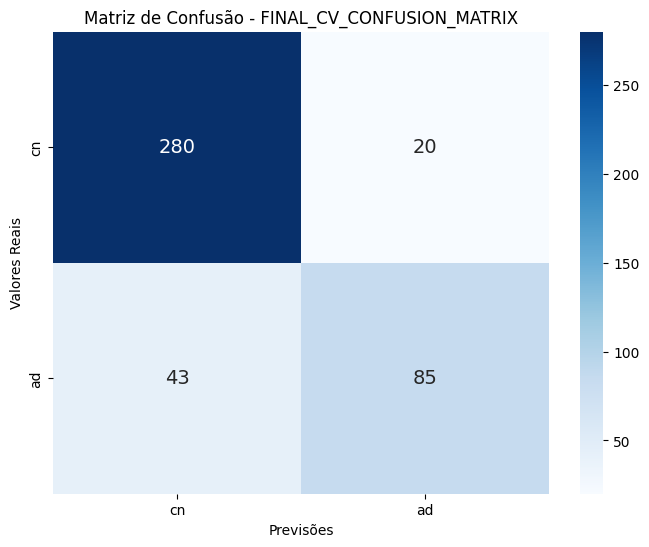

              precision    recall  f1-score   support

           0       0.87      0.93      0.90       300
           1       0.81      0.66      0.73       128

    accuracy                           0.85       428
   macro avg       0.84      0.80      0.81       428
weighted avg       0.85      0.85      0.85       428



In [15]:
# ==============================================================================
# 5. RESULTADOS GLOBAIS
# ==============================================================================
print("\n=== VALIDAÇÃO CRUZADA FINALIZADA ===")
print(f"Acurácia Média: {np.mean(fold_accuracies):.4f} (+/- {np.std(fold_accuracies):.4f})")
print(f"AUC Média: {np.mean(fold_aucs):.4f} (+/- {np.std(fold_aucs):.4f})")

aggregated_true = np.array(aggregated_true_labels)
aggregated_pred = np.array(aggregated_pred_labels)

met_vil.plot_confusion_matrix(
    aggregated_true, 
    aggregated_pred, 
    results_dir, 
    'FINAL_CV_CONFUSION_MATRIX', 
    fine_tunning_labels
)

met_vil.get_classification_report(
    aggregated_true, 
    aggregated_pred, 
    results_dir, 
    'FINAL_CV_REPORT'
)